## MACHINE LEARNING PROJECT | TOMANE

### Trying to predict the number of medals a country could win.

#### Importing libraries and the dataset

In [3]:
import pandas as pd

In [31]:
teams = pd.read_csv(r"C:\Users\Tomane Asus\OneDrive\Desktop\Personal Issues\OneDrive\Desktop\Projects\ML\teams.csv")

#### Visualize the Dataset

In [32]:
teams.tail(5)

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
2139,ZIM,Zimbabwe,2000,19,26,25.0,179.0,71.1,0,0.0,0.0
2140,ZIM,Zimbabwe,2004,11,14,25.1,177.8,70.5,3,0.0,0.0
2141,ZIM,Zimbabwe,2008,15,16,26.1,171.9,63.7,4,3.0,1.0
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3
2143,ZIM,Zimbabwe,2016,13,31,27.5,167.8,62.2,0,0.0,2.3


In [17]:
teams

,team,country,year,events,athletes,age,height,weight,medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0
...,...,...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,19,26,25.0,179.0,71.1,0
2140,ZIM,Zimbabwe,2004,11,14,25.1,177.8,70.5,3
2141,ZIM,Zimbabwe,2008,15,16,26.1,171.9,63.7,4
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0


#### Choosing the columns to work with

In [18]:
teams_1 = teams [["team", "country", "year",	"events",	"athletes",	"age",	"height",	"weight",	"medals"]]

In [19]:
teams_1

,team,country,year,events,athletes,age,height,weight,medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0
...,...,...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,19,26,25.0,179.0,71.1,0
2140,ZIM,Zimbabwe,2004,11,14,25.1,177.8,70.5,3
2141,ZIM,Zimbabwe,2008,15,16,26.1,171.9,63.7,4
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0


#### Trying to find the correlation between the medals and other columns

In [20]:
teams_1.corr(numeric_only=True)["medals"]

year       -0.021603
events      0.771330
athletes    0.840817
age         0.025096
height      0.141055
weight      0.090577
medals      1.000000
Name: medals, dtype: float64

In [34]:
teams.select_dtypes(include="number").corr()["medals"]

year            -0.021603
events           0.771330
athletes         0.840817
age              0.025096
height           0.141055
weight           0.090577
medals           1.000000
prev_medals      0.920048
prev_3_medals    0.918438
Name: medals, dtype: float64

#### Visualizing in graphics

In [36]:
numeric_data = teams.select_dtypes(include="number")

In [37]:
corr_matrix = numeric_data.corr()

In [39]:
corr_matrix

,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
year,1.000000,-0.016345,-0.056957,-0.012179,-0.001459,0.031400,-0.021603,-0.017917,-0.010385
events,-0.016345,1.000000,0.976446,0.053461,0.208067,0.127031,0.771330,0.752264,0.773115
athletes,-0.056957,0.976446,1.000000,0.036358,0.186134,0.109439,0.840817,0.810576,0.826720
age,-0.012179,0.053461,0.036358,1.000000,0.173694,0.220497,0.025096,0.032596,0.041833
height,-0.001459,0.208067,0.186134,0.173694,1.000000,0.687398,0.141055,0.138682,0.144322
weight,0.031400,0.127031,0.109439,0.220497,0.687398,1.000000,0.090577,0.088706,0.092196
medals,-0.021603,0.771330,0.840817,0.025096,0.141055,0.090577,1.000000,0.920048,0.918438
prev_medals,-0.017917,0.752264,0.810576,0.032596,0.138682,0.088706,0.920048,1.000000,0.968779
prev_3_medals,-0.010385,0.773115,0.826720,0.041833,0.144322,0.092196,0.918438,0.968779,1.000000


In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

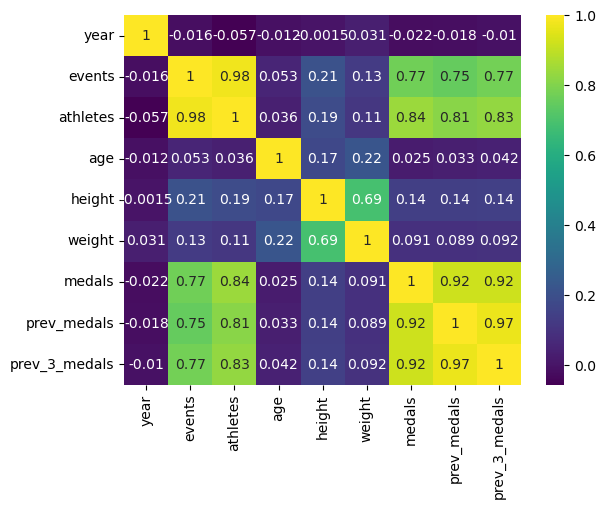

In [57]:
sns.heatmap(corr_matrix, annot=True, cmap="viridis")
plt.show()

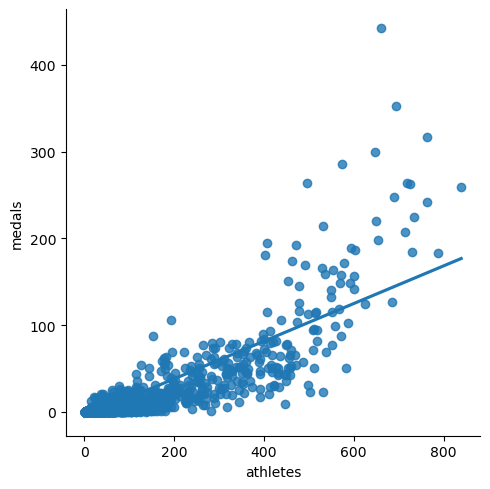

In [58]:
sns.lmplot(x="athletes", y="medals", data=teams, fit_reg=True, ci=None)

##### In general, the regression line shows that as the number of athletes a country sends increases, the number of medals it tends to win also increases.

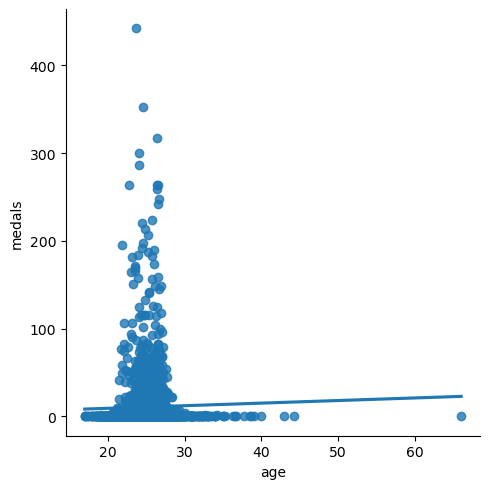

In [59]:
sns.lmplot(x="age", y="medals", data=teams, fit_reg=True, ci=None)

##### There's no strong relationship between the age of the athletes and the medals, and the age range of winners is in between 20 - 30 years old.

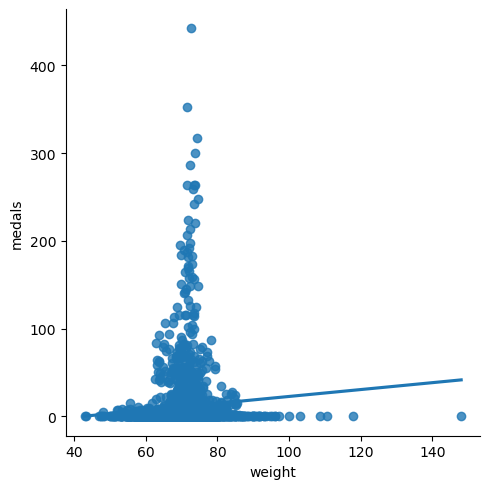

In [60]:
sns.lmplot(x="weight", y="medals", data=teams, fit_reg=True, ci=None)

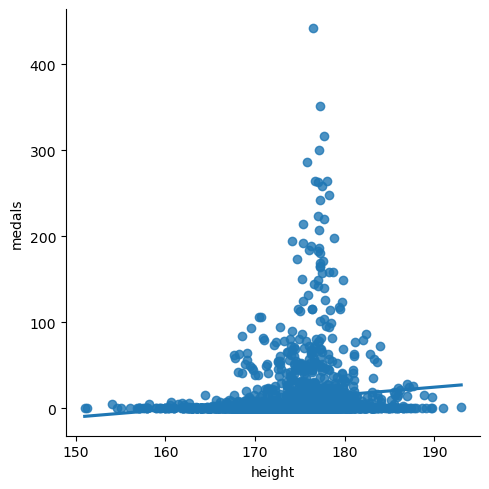

In [61]:
sns.lmplot(x="height", y="medals", data=teams, fit_reg=True, ci=None)

#### Lets explore with a quick histogram to look how many countries fall into each bin for medals they earned.

<Axes: ylabel='Frequency'>

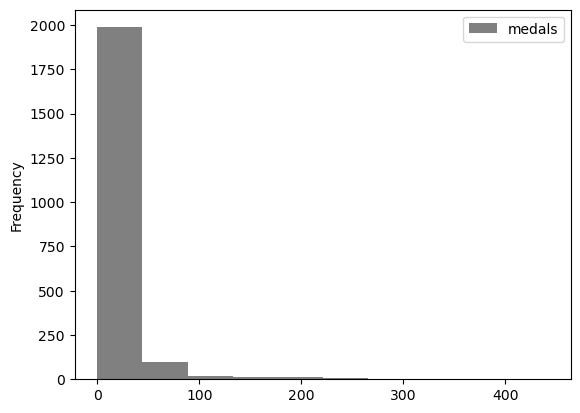

In [65]:
teams.plot.hist(y="medals", color="Grey")

##### So we can see that almost all the 2000 countries have earned between 0 and 50 medals in an olympics.

### Data Wrangling

##### Trying to find missing values

In [68]:
teams[teams.isnull().any(axis=1)]

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
19,ALB,Albania,1992,8,9,25.3,163.0,75.2,0,NaN,NaN
26,ALG,Algeria,1964,7,7,26.0,175.0,65.0,0,NaN,NaN
39,AND,Andorra,1976,2,3,28.3,174.7,78.0,0,NaN,NaN
50,ANG,Angola,1980,14,17,17.4,171.7,62.5,0,NaN,NaN
59,ANT,Antigua and Barbuda,1976,11,17,23.2,178.6,71.6,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2092,VIN,Saint Vincent and the Grenadines,1988,6,6,20.5,157.0,57.0,0,NaN,NaN
2103,YAR,North Yemen,1984,3,3,27.7,163.3,57.7,0,NaN,NaN
2105,YEM,Yemen,1992,8,8,19.6,169.0,60.0,0,NaN,NaN
2112,YMD,South Yemen,1988,5,5,23.6,175.0,63.3,0,NaN,NaN


#### Lets remove all the rows with missing values

In [76]:
teams = teams.dropna()

In [77]:
teams

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals
0,AFG,Afghanistan,1964,8,8,22.0,161.0,64.2,0,0.0,0.0
1,AFG,Afghanistan,1968,5,5,23.2,170.2,70.0,0,0.0,0.0
2,AFG,Afghanistan,1972,8,8,29.0,168.3,63.8,0,0.0,0.0
3,AFG,Afghanistan,1980,11,11,23.6,168.4,63.2,0,0.0,0.0
4,AFG,Afghanistan,2004,5,5,18.6,170.8,64.8,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2139,ZIM,Zimbabwe,2000,19,26,25.0,179.0,71.1,0,0.0,0.0
2140,ZIM,Zimbabwe,2004,11,14,25.1,177.8,70.5,3,0.0,0.0
2141,ZIM,Zimbabwe,2008,15,16,26.1,171.9,63.7,4,3.0,1.0
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3


<Axes: ylabel='Frequency'>

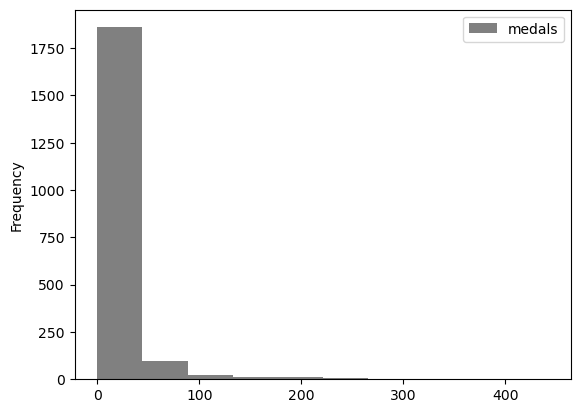

In [71]:
teams.plot.hist(y="medals", color="Grey")

### Now we are going to train ou model

##### The next thing is to split our data up, bcz these data are time series, some rows come before other rows, so we want to split in a way that respects that. We are going to take the last two years of data we have (2012 and 2016) and put them in our test dataset and take the previous years and put them in our train dataset. The reason is that in the real world if we're trying to predict who's going to win the most medals in the olympics in 2024, we dont have access to data from 2028 for example, we only have data from the past.

In [74]:
train = teams[teams["year"] < 2012].copy()
test = teams[teams["year"] >= 2012].copy()

In [75]:
train.Shape

(1609, 11)

In [78]:
test.shape

(405, 11)

In [79]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

In [80]:
predictors = ["athletes", "prev_medals"]
target = "medals"

In [83]:
reg.fit(train[predictors], train["medals"])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [84]:
predictions = reg.predict(test[predictors])

In [85]:
predictions

array([-9.61221245e-01, -1.17633261e+00, -1.42503158e+00, -1.71184673e+00,
        2.15562926e+00,  3.91463636e+00, -1.71184673e+00, -1.85525431e+00,
        3.67563128e-01, -2.77770967e-01, -1.85525431e+00, -1.49673537e+00,
        4.67519911e+01,  2.87550937e+01,  4.58450091e+00,  2.54773581e+00,
       -1.85525431e+00, -1.64014295e+00, -1.85525431e+00, -1.85525431e+00,
        1.46556876e+02,  1.20571799e+02,  6.56314795e+00,  3.95275254e+00,
        7.34283247e+00,  1.03117468e+01,  5.19171882e+00,  3.58517645e+00,
       -1.64014295e+00, -1.64014295e+00, -1.56843916e+00, -1.20992022e+00,
       -1.71184673e+00, -1.42503158e+00,  1.17929959e+01,  1.00049298e+01,
       -1.78355052e+00, -1.71184673e+00, -1.56843916e+00, -1.56843916e+00,
       -1.99866189e+00, -1.99866189e+00, -1.56843916e+00, -1.35332779e+00,
       -1.92695810e+00, -1.92695810e+00,  3.28912706e+01,  2.53042547e+01,
       -1.78355052e+00, -1.28162400e+00, -1.85525431e+00, -3.87590939e-01,
        7.83480779e+01,  

##### This is a numpy array. 
1. These numbers are not rounded, which doesnt make sense in our scenario, its possible to win a whole number and not half medal. 
2. Some of these values are negative, so countries can not get a negative number of medals.

##### So we are going to do some quick corrections to avoid the issues above.

In [86]:
test["predictions"] = predictions

In [88]:
test

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals,predictions
6,AFG,Afghanistan,2012,6,6,24.8,171.7,60.8,1,1.0,0.3,-0.961221
7,AFG,Afghanistan,2016,3,3,24.7,173.7,74.0,0,1.0,0.7,-1.176333
24,ALB,Albania,2012,9,10,25.7,176.8,80.2,0,0.0,0.0,-1.425032
25,ALB,Albania,2016,6,6,23.7,176.2,67.2,0,0.0,0.0,-1.711847
37,ALG,Algeria,2012,29,39,24.8,174.3,66.9,1,2.0,2.3,2.155629
...,...,...,...,...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,3,19.3,169.7,65.7,0,0.0,0.0,-1.926958
2131,ZAM,Zambia,2012,7,7,22.6,176.2,74.2,0,0.0,0.0,-1.640143
2132,ZAM,Zambia,2016,7,7,24.1,175.2,67.5,0,0.0,0.0,-1.640143
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3,1.505767


In [89]:
test.loc[test["predictions"] < 0, "predictions"] = 0

In [90]:
test["predictions"] = test ["predictions"].round()

In [91]:
test

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals,predictions
6,AFG,Afghanistan,2012,6,6,24.8,171.7,60.8,1,1.0,0.3,0.0
7,AFG,Afghanistan,2016,3,3,24.7,173.7,74.0,0,1.0,0.7,0.0
24,ALB,Albania,2012,9,10,25.7,176.8,80.2,0,0.0,0.0,0.0
25,ALB,Albania,2016,6,6,23.7,176.2,67.2,0,0.0,0.0,0.0
37,ALG,Algeria,2012,29,39,24.8,174.3,66.9,1,2.0,2.3,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2111,YEM,Yemen,2016,3,3,19.3,169.7,65.7,0,0.0,0.0,0.0
2131,ZAM,Zambia,2012,7,7,22.6,176.2,74.2,0,0.0,0.0,0.0
2132,ZAM,Zambia,2016,7,7,24.1,175.2,67.5,0,0.0,0.0,0.0
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3,2.0


In [92]:
from sklearn.metrics import mean_absolute_error

In [93]:
error = mean_absolute_error(test["medals"], test["predictions"])

In [94]:
error

3.2987654320987656

#### This means we were within on average 3.3 medals of how many medals a team actually won in the Olympics. 

##### Lets investigate whether this mean error is a good value or not.

In [96]:
teams.describe()["medals"]

count    2014.000000
mean       10.990070
std        33.627528
min         0.000000
25%         0.000000
50%         0.000000
75%         5.000000
max       442.000000
Name: medals, dtype: float64

##### Its important to check if the mean error is not higher than the std, if so something is wrong. The mean_absolute_error must be lower than the std.

#### Now lets see the predictions for each team.

In [97]:
test[test["team"] == "USA"]

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals,predictions
2053,USA,United States,2012,245,689,26.7,178.3,74.7,248,317.0,274.0,285.0
2054,USA,United States,2016,245,719,26.4,178.0,73.8,264,248.0,276.0,236.0


In [98]:
test[test["team"] == "ZIM"]

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals,predictions
2142,ZIM,Zimbabwe,2012,8,9,27.3,174.4,65.2,0,4.0,2.3,2.0
2143,ZIM,Zimbabwe,2016,13,31,27.5,167.8,62.2,0,0.0,2.3,0.0


In [99]:
test[test["country"] == "Mozambique"]

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals,predictions
1358,MOZ,Mozambique,2012,6,6,22.2,172.3,65.6,0,0.0,0.3,0.0
1359,MOZ,Mozambique,2016,7,8,24.1,173.9,68.1,0,0.0,0.0,0.0


In [100]:
test[test["country"] == "China"]

,team,country,year,events,athletes,age,height,weight,medals,prev_medals,prev_3_medals,predictions
404,CHN,China,2012,206,479,24.0,175.4,68.6,125,184.0,119.0,170.0
405,CHN,China,2016,209,499,24.0,175.0,68.0,113,125.0,134.3,127.0


#### Lets determine the absolute error for all the countries

In [103]:
errors = (test["medals"] - test["predictions"]).abs()

In [104]:
errors

6       1.0
7       0.0
24      0.0
25      0.0
37      1.0
       ... 
2111    0.0
2131    0.0
2132    0.0
2142    2.0
2143    0.0
Length: 405, dtype: float64

In [106]:
error_by_team = errors.groupby(test["team"]).mean()

In [107]:
error_by_team

team
AFG    0.5
ALB    0.0
ALG    1.5
AND    0.0
ANG    0.0
      ... 
VIE    1.0
VIN    0.0
YEM    0.0
ZAM    0.0
ZIM    1.0
Length: 204, dtype: float64

#### Now lets see how many medals each country earns on average

In [109]:
medals_by_team = test["medals"].groupby(test["team"]).mean()

In [110]:
error_ratio = error_by_team / medals_by_team

In [111]:
error_ratio

team
AFG    1.0
ALB    NaN
ALG    1.0
AND    NaN
ANG    NaN
      ... 
VIE    1.0
VIN    NaN
YEM    NaN
ZAM    NaN
ZIM    inf
Length: 204, dtype: float64

#### Lets count countries that have no missing values

In [112]:
error_ratio[~pd.isnull(error_ratio)]

team
AFG    1.000000
ALG    1.000000
ARG    0.853659
ARM    0.428571
AUS    0.367347
         ...   
USA    0.126953
UZB    0.625000
VEN    1.750000
VIE    1.000000
ZIM         inf
Length: 102, dtype: float64

##### Lets clean also the inf values

In [116]:
import numpy as np
error_ratio = error_ratio[np.isfinite(error_ratio)]

In [117]:
error_ratio

team
AFG    1.000000
ALG    1.000000
ARG    0.853659
ARM    0.428571
AUS    0.367347
         ...   
UKR    0.951220
USA    0.126953
UZB    0.625000
VEN    1.750000
VIE    1.000000
Length: 97, dtype: float64

<Axes: ylabel='Frequency'>

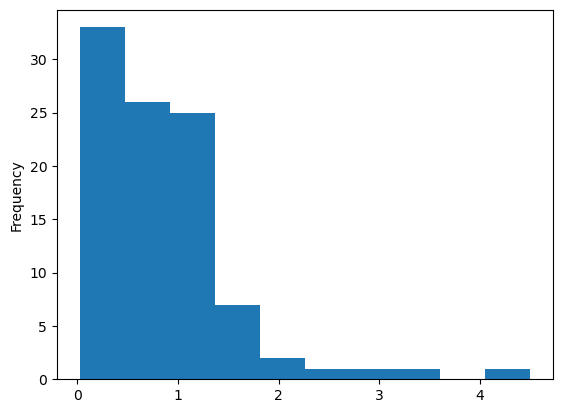

In [118]:
error_ratio.plot.hist()

In [119]:
 error_ratio.sort_values()

team
FRA    0.022472
CAN    0.048387
NZL    0.063492
RUS    0.082353
ITA    0.121429
         ...   
MAR    2.000000
EGY    2.400000
HKG    3.000000
POR    3.333333
AUT    4.500000
Length: 97, dtype: float64

### In order to improve the model, we can: 
1. Add more predictors.
2. Try different models like neural network, random forest, etc